# Correction Metrics And Latency

This notebook evaluates final text correction quality for the N-gram and RNN models using held-out SPECIL rows.

Metrics:
- WER: word error rate
- CER: character error rate
- Precision, recall, F1 for changed typo words
- Inference latency in milliseconds

Note: the current project does not run N-gram or RNN on ESP32. ESP32 only sends text to the laptop backend. Latency here measures local laptop inference time, which is the actual current runtime path.

In [1]:
from pathlib import Path
import csv
import statistics
import sys
import time

ROOT = Path.cwd()
if not (ROOT / 'app.py').exists():
    ROOT = ROOT.parent.parent

sys.path.insert(0, str(ROOT / 'model' / 'n_gram'))
sys.path.insert(0, str(ROOT / 'model' / 'RNN'))

from ngram_spell_checker import NGramSpellChecker, tokenize_words
try:
    from specil_rnn_spellchecker import SpecilRnnSpellChecker, words
    RNN_AVAILABLE = True
except ModuleNotFoundError as e:
    SpecilRnnSpellChecker = None
    words = None
    RNN_AVAILABLE = False
    print('RNN skipped:', e)
    print('Use the project .env kernel or run: .env\\python.exe -m pip install tensorflow')

TEST_PATH = ROOT / 'model' / 'specil_test.csv'
MAX_ROWS = 500
print(ROOT)


e:\8. Mata Kuliah\Semester 6\IoT Kecerdasan Artifisial\FinalProject_MorseNLP


In [2]:
def levenshtein(a, b):
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[-1] + 1, prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]

def wer(reference, hypothesis):
    ref = reference.split()
    hyp = hypothesis.split()
    return levenshtein(ref, hyp) / max(len(ref), 1)

def cer(reference, hypothesis):
    return levenshtein(reference, hypothesis) / max(len(reference), 1)

def load_pairs(limit=MAX_ROWS):
    rows = []
    with TEST_PATH.open(encoding='utf-8', newline='') as f:
        for row in csv.DictReader(f):
            rows.append((row['wrong_text'], row['correct_text'], row['error_type']))
            if len(rows) >= limit:
                break
    return rows

pairs = load_pairs()
len(pairs), pairs[:2]

(500,
 [('diskusikan gambar sampul di atas dengan menawab pertanyaan-pertanyaan ini .',
   'diskusikan gambar sampul di atas dengan menjawab pertanyaan-pertanyaan ini .',
   'Deletion Error'),
  ('bola boni bir .', 'bola boni biru .', 'Deletion Error')])

In [3]:
ngram = NGramSpellChecker.load(ROOT / 'model' / 'n_gram' / 'ngram_spell_checker.json.gz')

def evaluate_model(name, correct_fn, tokenize_fn):
    wers, cers, latencies = [], [], []
    tp = fp = fn = tn = 0
    for wrong, target, _ in pairs:
        start = time.perf_counter()
        pred = correct_fn(wrong)
        latencies.append((time.perf_counter() - start) * 1000)
        wers.append(wer(target, pred))
        cers.append(cer(target, pred))

        wrong_tokens = tokenize_fn(wrong)
        target_tokens = tokenize_fn(target)
        pred_tokens = tokenize_fn(pred)
        for w, t, p in zip(wrong_tokens, target_tokens, pred_tokens):
            needed = w != t
            changed = w != p
            correct = p == t
            if changed and needed and correct:
                tp += 1
            elif changed and not correct:
                fp += 1
            elif needed and not correct:
                fn += 1
            elif not needed and not changed:
                tn += 1

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return {
        'model': name,
        'rows': len(pairs),
        'wer_percent': statistics.mean(wers) * 100,
        'cer_percent': statistics.mean(cers) * 100,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'latency_ms_mean': statistics.mean(latencies),
        'latency_ms_median': statistics.median(latencies),
        'latency_ms_max': max(latencies),
    }

ngram_result = evaluate_model('n_gram', ngram.correct, tokenize_words)
if RNN_AVAILABLE:
    rnn = SpecilRnnSpellChecker.load()
    rnn_result = evaluate_model('rnn', rnn.correct, words)
else:
    rnn_result = {'model': 'rnn', 'skipped': 'TensorFlow is not installed in this notebook kernel'}
ngram_result, rnn_result


({'model': 'n_gram',
  'rows': 500,
  'wer_percent': 5.631035573998451,
  'cer_percent': 1.6215999359748705,
  'precision': 0.7385786802030457,
  'recall': 0.7311557788944724,
  'f1': 0.7348484848484849,
  'tp': 291,
  'fp': 103,
  'fn': 107,
  'tn': 3023,
  'latency_ms_mean': 65.00544459996308,
  'latency_ms_median': 51.56780000288563,
  'latency_ms_max': 460.87139999872306},
 {'model': 'rnn',
  'rows': 500,
  'wer_percent': 37.97781285435274,
  'cer_percent': 4.061915724102745,
  'precision': 0.9388297872340425,
  'recall': 0.7384937238493724,
  'f1': 0.8266978922716628,
  'tp': 353,
  'fp': 23,
  'fn': 125,
  'tn': 3732,
  'latency_ms_mean': 1463.992537599952,
  'latency_ms_median': 0.03904999903170392,
  'latency_ms_max': 36238.05599999832})

In [4]:
for result in (ngram_result, rnn_result):
    print('\n' + result['model'])
    for key, value in result.items():
        if key != 'model':
            print(f'{key}: {value}')


n_gram
rows: 500
wer_percent: 5.631035573998451
cer_percent: 1.6215999359748705
precision: 0.7385786802030457
recall: 0.7311557788944724
f1: 0.7348484848484849
tp: 291
fp: 103
fn: 107
tn: 3023
latency_ms_mean: 65.00544459996308
latency_ms_median: 51.56780000288563
latency_ms_max: 460.87139999872306

rnn
rows: 500
wer_percent: 37.97781285435274
cer_percent: 4.061915724102745
precision: 0.9388297872340425
recall: 0.7384937238493724
f1: 0.8266978922716628
tp: 353
fp: 23
fn: 125
tn: 3732
latency_ms_mean: 1463.992537599952
latency_ms_median: 0.03904999903170392
latency_ms_max: 36238.05599999832


## Interpretation

- Lower WER/CER is better.
- Higher precision means fewer valid words were damaged.
- Higher recall means more actual typos were fixed.
- Higher F1 means a better balance between precision and recall.
- Lower latency is better for real-time use.

For the current architecture, ESP32 latency also includes Wi-Fi and FastAPI request time. This notebook measures model inference only.

## Matplotlib Performance Dashboard

This section visualizes WER, CER, precision, recall, F1, latency, and correction confusion matrices. Install matplotlib with `.env\python.exe -m pip install matplotlib` before running these cells.

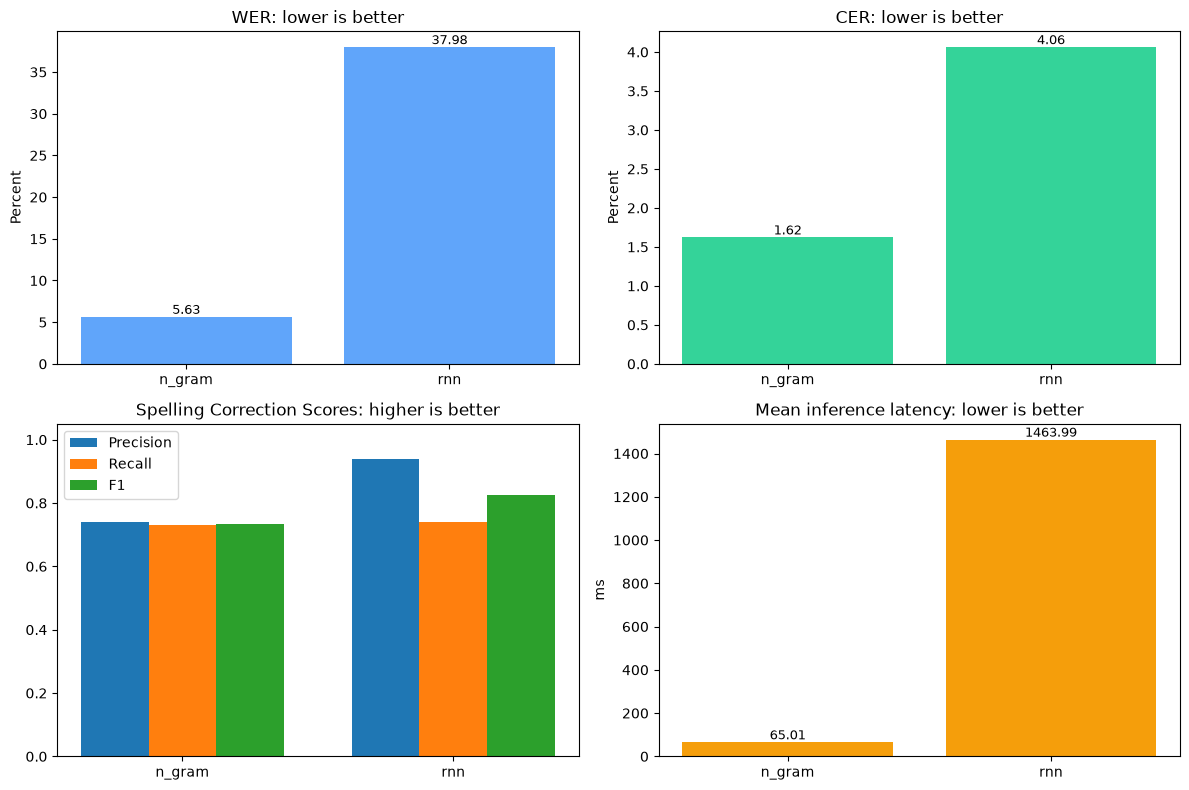

In [5]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as e:
    raise ModuleNotFoundError('matplotlib is required. Run: .env\\python.exe -m pip install matplotlib') from e

results = [r for r in (ngram_result, rnn_result) if 'skipped' not in r]
if not results:
    raise RuntimeError('No model results available to plot.')

def labels():
    return [r['model'] for r in results]

def annotate_bars(ax):
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=9)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.bar(labels(), [r['wer_percent'] for r in results], color='#60a5fa')
ax.set_title('WER: lower is better')
ax.set_ylabel('Percent')
annotate_bars(ax)

ax = axes[0, 1]
ax.bar(labels(), [r['cer_percent'] for r in results], color='#34d399')
ax.set_title('CER: lower is better')
ax.set_ylabel('Percent')
annotate_bars(ax)

ax = axes[1, 0]
x = range(len(results))
width = 0.25
ax.bar([i - width for i in x], [r['precision'] for r in results], width=width, label='Precision')
ax.bar(list(x), [r['recall'] for r in results], width=width, label='Recall')
ax.bar([i + width for i in x], [r['f1'] for r in results], width=width, label='F1')
ax.set_title('Spelling Correction Scores: higher is better')
ax.set_xticks(list(x), labels())
ax.set_ylim(0, 1.05)
ax.legend()

ax = axes[1, 1]
ax.bar(labels(), [r['latency_ms_mean'] for r in results], color='#f59e0b')
ax.set_title('Mean inference latency: lower is better')
ax.set_ylabel('ms')
annotate_bars(ax)

plt.tight_layout()
plt.show()


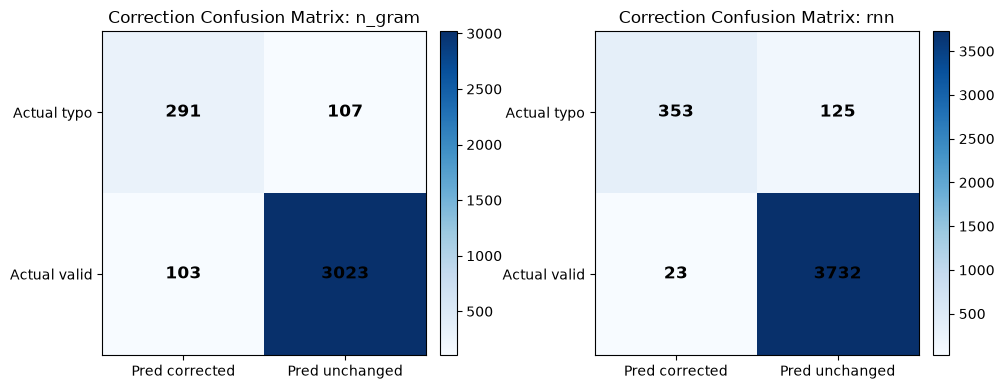

In [6]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
if len(results) == 1:
    axes = [axes]

for ax, result in zip(axes, results):
    matrix = [[result['tp'], result['fn']], [result['fp'], result['tn']]]
    image = ax.imshow(matrix, cmap='Blues')
    ax.set_title(f"Correction Confusion Matrix: {result['model']}")
    ax.set_xticks([0, 1], ['Pred corrected', 'Pred unchanged'])
    ax.set_yticks([0, 1], ['Actual typo', 'Actual valid'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, matrix[i][j], ha='center', va='center', color='black', fontsize=12, fontweight='bold')
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
